# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers + summaries
    read_hrs1, read_hrs2, find_hrs_files,
    print_hrs1_summary, print_hrs2_summary,
    # Post-hoc global windowing
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    # M/H response variability vs EMG window size
    compute_trial_responses, print_response_stats,
    compute_response_variability_sweep,
    plot_response_variability_sweep, plot_response_variability_combined,
    print_variability_summary, view_variability_bin,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [8]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field):
#   HRPILOT-14-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-14-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-15-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-15-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "HR16__CONFIGB_POST_HOC_SINGLE_FIXED" #"HR16_POST_HOC_SINGLE_FIXED"

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found — HRS2 sections will be skipped")


Recording directory: HR16__CONFIGB_POST_HOC_SINGLE_FIXED
  HRS1 file: HR16__CONFIGB_POST_HOC_SINGLE_FIXED_20260501T171329.hrs1
  HRS2 file: HR16__CONFIGB_POST_HOC_SINGLE_FIXED_20260501T161739.hrs2


In [9]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               HR16__CONFIGB_POST_HOC_SINGLE_FIXED_20260501T171329.hrs1
  File version:       0
  Subject ID:         HR16__CONFIGB_POST_HOC_SINGLE_FIXED
  Session datetime:   2026-05-01 17:13:29.249426
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=338.01 µV, elapsed=0.006 h, 20 window sizes

  Trials found:       3
  EMG data blocks:    567

=== First Trial ===
  End datetime:       2026-05-01 17:13:43.604709
  Start index:        0
  Grand mean:         338.6502
  Bins count:         54
  Monitored signal N: 13500

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1']
  Raw channels:       3 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  Abs samples:        191


# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [10]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               HR16__CONFIGB_POST_HOC_SINGLE_FIXED_20260501T161739.hrs2
  File version:       3  (v3: + unipolar_trial_data)
  Subject ID:         HR16__CONFIGB_POST_HOC_SINGLE_FIXED
  Session start time: 2026-05-01 16:17:39.289121
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       600
  EMG data blocks:    49189

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1']
  Raw channels:   3 x 191 samples
  Diff samples:   191


# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, and extract per-trial pre-stim grand means.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean directly from `trial_data` and plot the distribution.

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 49,189
  Total samples   : 3,282,281
  Duration        : 656.5 s  (10.9 min)
  OE sample range : 1777670259264 – 1777673541545
  Gap samples     : 1,329,274  (40.498% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 600
  Unmapped (no onset) : 600
  Non-blanked samples : 3,282,281  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 3,282,281
  Mean    : 187.997 µV
  Std     : 293.020 µV
  Q1      : 0.000 µV
  Median  : 40.585 µV
  Q3      : 282.273 µV


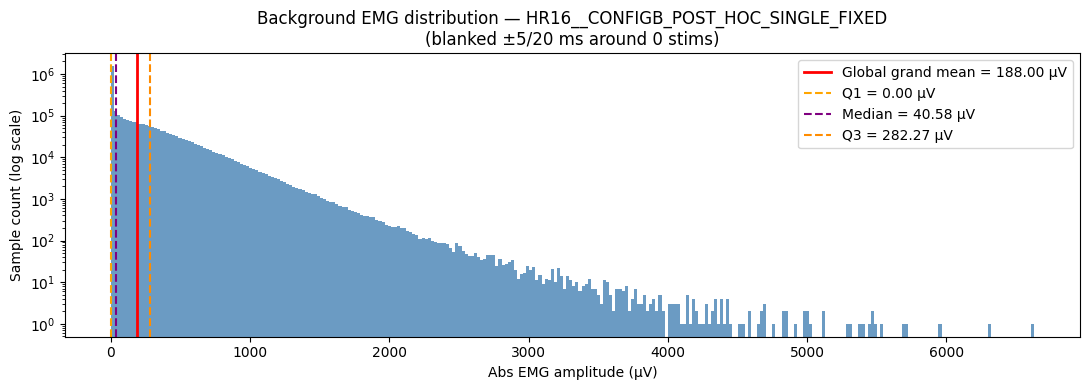


Section 4d: Per-trial pre-stim background grand means
  Trials : 600
  Min=8.11  Q1=267.46  Median=323.29  Q3=374.42  Max=643.45
  Recorded thresholds (mean): [0.00, 500.00] µV


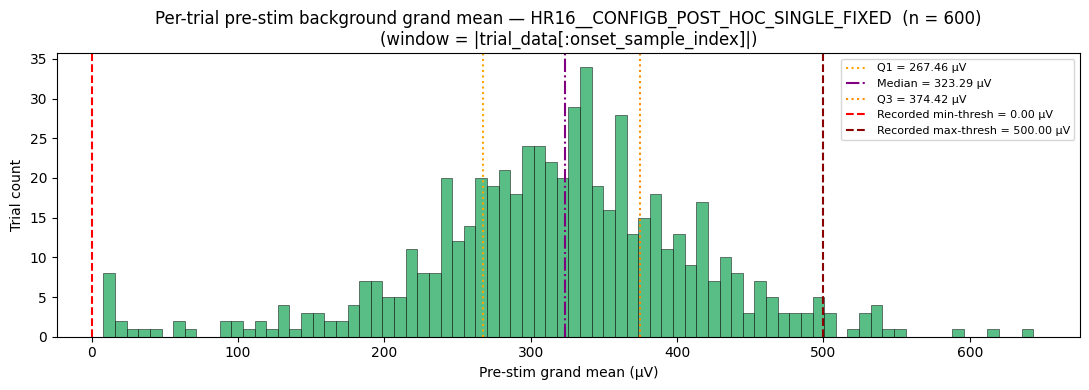

In [11]:
# ---- Section 4: Post-hoc global windowing analysis ----
# Stitches continuous |EMG| from hrs2_emg_blocks, blanks ±[5,20] ms around each
# stim event, computes background statistics, and per-trial pre-stim grand means.
# Returns a state dict consumed by Section 5.
state = analyze_global_background(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=hrs1_header.sample_rate,
    blank_pre_ms=5, blank_post_ms=20,
    min_valid_frac=0.7,
)

# Section 5: Post-Hoc Threshold Sweep

Simulate the trial-initiation algorithm on the full continuous HRS2 background signal with different `(min_uv, max_uv)` threshold windows.

`sweep_trials()` walks the signal with randomised 2200–2700 ms monitoring windows — the same algorithm the app uses in real time.  We test window centres at **Q1**, **Median**, and **Q3** of the per-trial pre-stim background distribution, sweeping over a range of half-widths.

In [12]:
# ---- Section 5a: Threshold sweep ----
# Defaults: centres = {Q1, Median, Q3} of per-trial pre-stim background;
#           half-widths = [5, 10, 20, 30, 50, 75, 100, 150] µV.
# Pass `sweep_centres=` / `half_widths_uv=` to override.
sweep_results = run_threshold_sweep(state, n_trials=len(hrs2_trials))

Section 5a: Running post-hoc threshold sweep
Signal duration : 656.5 s | Non-blanked: 100.0%
Background stats: mean=188.00  Q1=267.46  Med=323.29  Q3=374.42 µV

  Q1     (centre=267.46 µV):  ±5→25  ±10→28  ±20→41  ±30→63  ±50→113  ±75→184  ±100→234  ±150→264
  Median (centre=323.29 µV):  ±5→3  ±10→3  ±20→5  ±30→5  ±50→12  ±75→40  ±100→94  ±150→231
  Q3     (centre=374.42 µV):  ±5→1  ±10→1  ±20→2  ±30→3  ±50→4  ±75→5  ±100→12  ±150→92

  Actual HRS2 trials recorded during session: 600


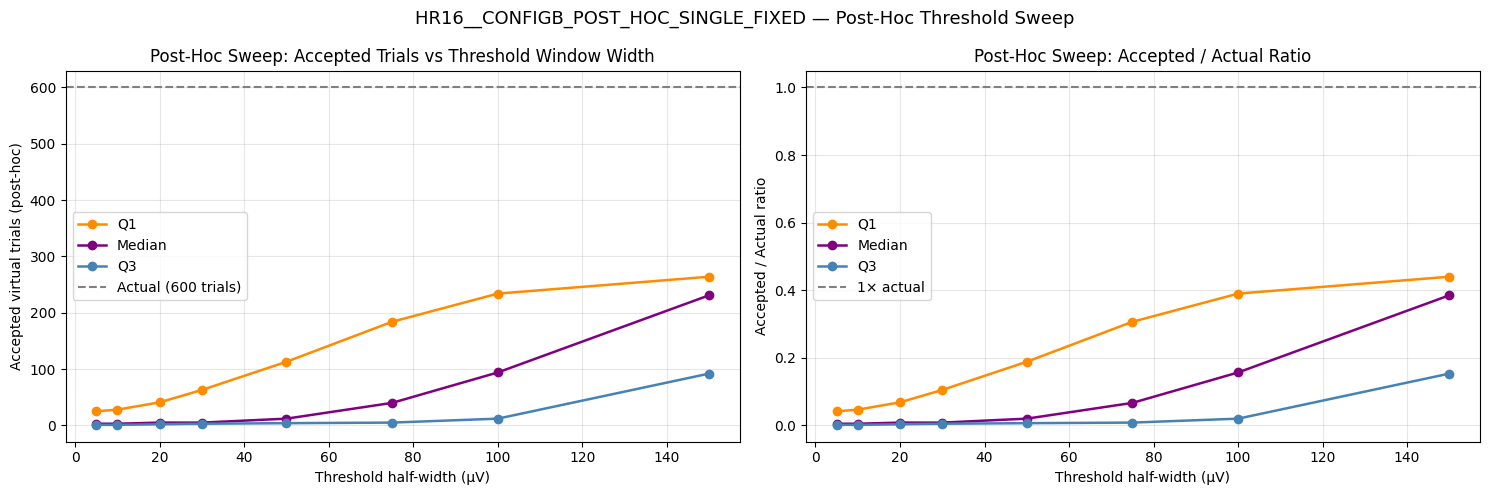

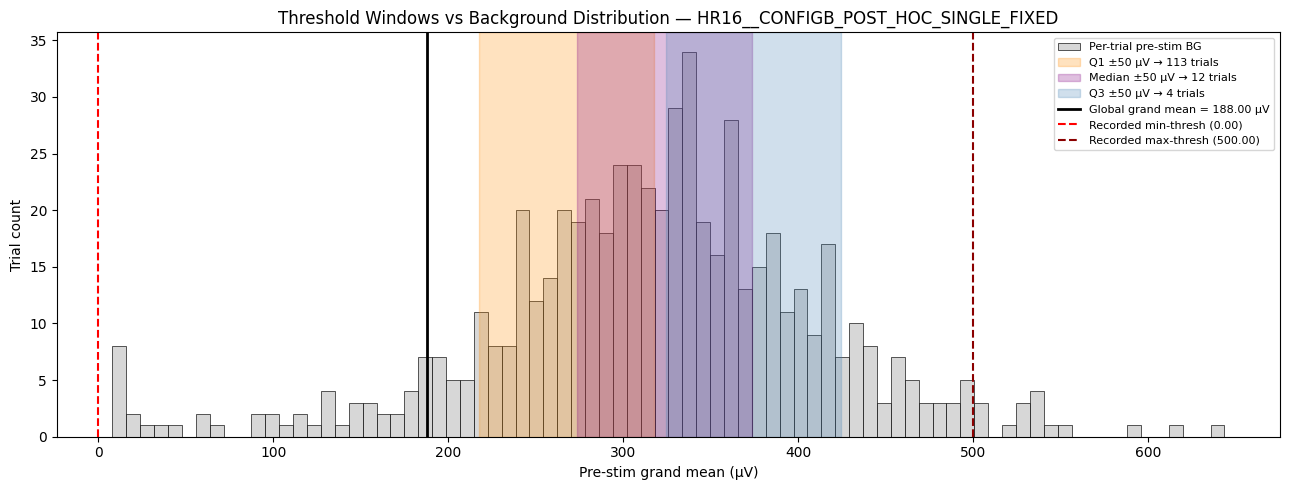


Global EMG grand mean = 187.997 µV  (std = 293.020, Q1 = 0.000, median = 40.585, Q3 = 282.273)
This is the divisor used downstream for normalising M-/H-wave sizes.

    Centre   ±hw (µV)   Min (µV)   Max (µV)   Accepted    vs Actual
-------------------------------------------------------------------
        Q1          5     262.46     272.46         25        0.04×
        Q1         10     257.46     277.46         28        0.05×
        Q1         20     247.46     287.46         41        0.07×
        Q1         30     237.46     297.46         63        0.10×
        Q1         50     217.46     317.46        113        0.19×
        Q1         75     192.46     342.46        184        0.31×
        Q1        100     167.46     367.46        234        0.39×
        Q1        150     117.46     417.46        264        0.44×

    Median          5     318.29     328.29          3        0.01×
    Median         10     313.29     333.29          3        0.01×
    Median       

In [13]:
# ---- Section 5b: Visualise threshold-sweep results ----
plot_threshold_sweep(sweep_results, state, hrs2_trials, hrs2_header)

# Section 6: M-/H-Response Size Variability vs EMG Window Size

For every trial we measure two response sizes inside the M and H windows:

- **Peak-to-peak**  — `max(emg) - min(emg)`
- **Peak amplitude** — `max(|emg|)`

Each size is normalised by the trial's **"Most Recent Background"** (per-trial pre-stim grand mean). Then for centres at **Q1 / Median / Q3** of the background distribution we sweep a half-width `hw`, group trials whose background falls in `[centre ± hw]`, and compute the standard deviation of the normalised M and H sizes inside each bin — the "Avg Size Variability" plotted below.

The output is:

1. A stacked plot — **top:** peak-to-peak variability, **bottom:** peak-amplitude variability — each with six curves (Q1/Median/Q3 × M/H) and 10 equally-spaced vertical markers.
2. A summary table at the 10 marker half-widths, one row per (centre, marker), showing min/max bin edges, `n`, M-/H-variability, and M-/H-mean.
3. An interactive viewer over the same marker bins.

In [14]:
# ---- Section 6a: Per-trial responses + variability sweeps (ptp + peak) ----
# Sizes are normalised by the GLOBAL EMG grand mean (state['bg_mean']) — same
# divisor for every trial. The variability sweep still groups by per-trial
# background level (state['trial_bg_gm']).
M_START_MS, M_END_MS = 3.0, 5.5
H_START_MS, H_END_MS = 6.5, 11.5


ptp_responses = compute_trial_responses(
    hrs2_trials, state['bg_mean'],
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    metric='ptp',
)
peak_responses = compute_trial_responses(
    hrs2_trials, state['bg_mean'],
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    metric='peak',
)

sweep_centres = {'Q1': state['gm_q1'],
                 'Median': state['gm_med'],
                 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 50, 75, 100, 150]

ptp_variability = compute_response_variability_sweep(
    state['trial_bg_gm'], ptp_responses,
    sweep_centres, half_widths_uv, metric='std',
)
peak_variability = compute_response_variability_sweep(
    state['trial_bg_gm'], peak_responses,
    sweep_centres, half_widths_uv, metric='std',
)

print(f"Global EMG grand mean (divisor) = {state['bg_mean']:.3f} µV "
      f"(std = {state['bg_std']:.3f})\n")
print_response_stats(ptp_responses, hrs2_header, label_prefix='Peak-to-peak')
print_response_stats(peak_responses, hrs2_header, label_prefix='Peak amplitude')

Global EMG grand mean (divisor) = 187.997 µV (std = 293.020)

=== HR16__CONFIGB_POST_HOC_SINGLE_FIXED — Peak-to-peak response statistics  (metric=ptp, bg_divisor=187.997 µV (scalar)) ===
  M-size (raw, µV):
    n      = 600
    mean   = 2816.0068
    median = 2772.2148
    std    = 637.0588
    var    = 405843.8913
    sem    = 26.0078
    min    = 84.6590
    max    = 6526.9785
  H-size (raw, µV):
    n      = 600
    mean   = 3452.5819
    median = 3246.0708
    std    = 1545.4926
    var    = 2388547.2930
    sem    = 63.0945
    min    = 385.2603
    max    = 9702.5098
  M-norm (size / bg):
    n      = 600
    mean   = 14.9790
    median = 14.7460
    std    = 3.3887
    var    = 11.4830
    sem    = 0.1383
    min    = 0.4503
    max    = 34.7185
  H-norm (size / bg):
    n      = 600
    mean   = 18.3651
    median = 17.2666
    std    = 8.2208
    var    = 67.5820
    sem    = 0.3356
    min    = 2.0493
    max    = 51.6099

=== HR16__CONFIGB_POST_HOC_SINGLE_FIXED — Peak amplit

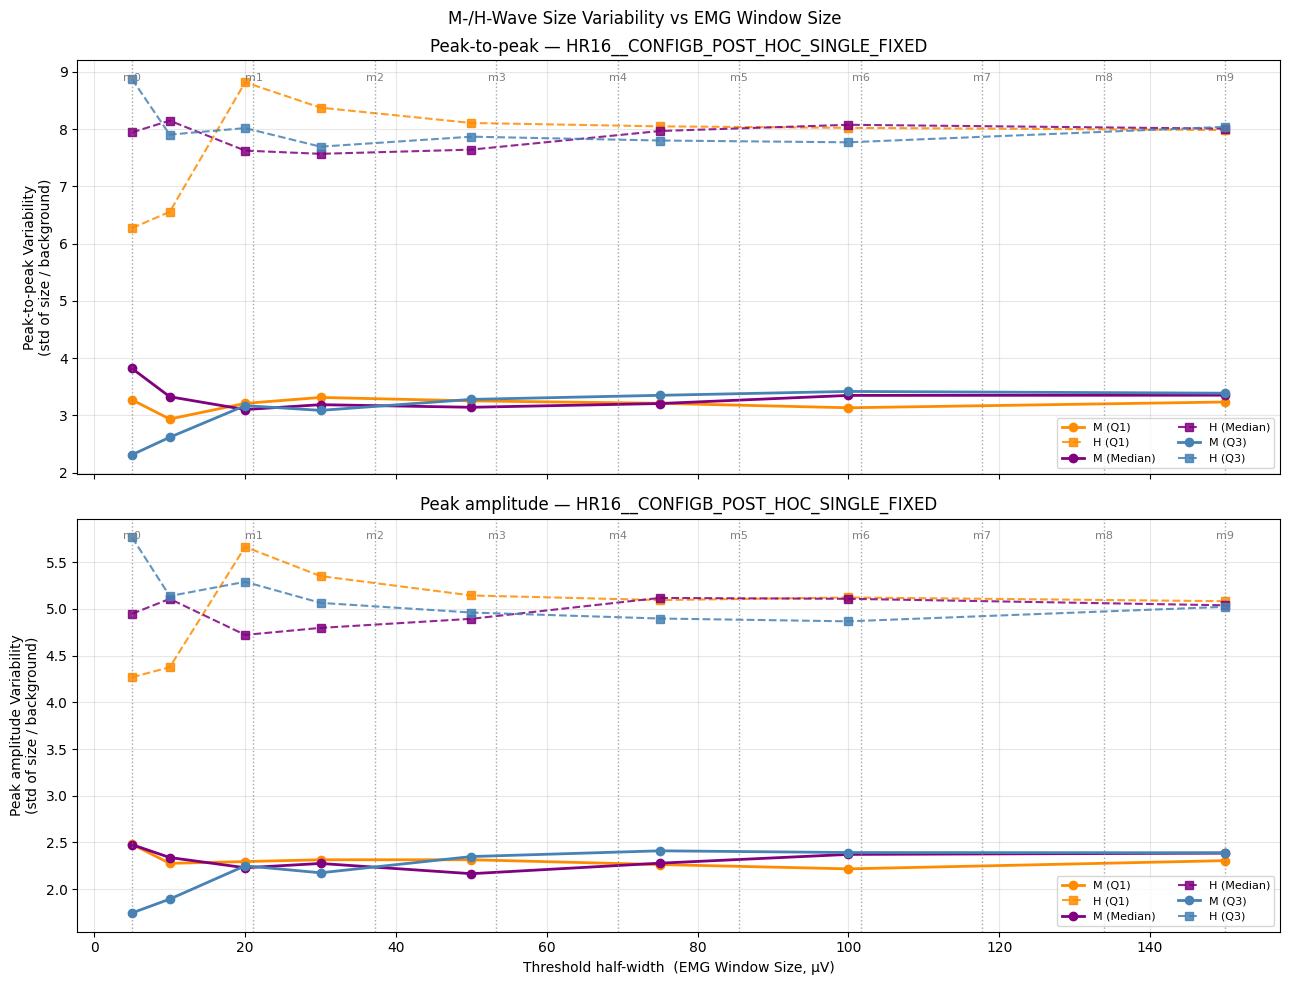

Marker half-widths: ['5.0', '21.1', '37.2', '53.3', '69.4', '85.6', '101.7', '117.8', '133.9', '150.0']


In [15]:
# ---- Section 6b: Combined plot (ptp top, peak bottom) ----
marker_hws = plot_response_variability_combined(
    ptp_variability, peak_variability, hrs2_header, n_markers=10,
)
print(f"Marker half-widths: {[f'{hw:.1f}' for hw in marker_hws]}")

In [16]:
# ---- Section 6c: Summary tables at the 10 marker half-widths ----
# Re-run the sweep at the exact marker positions so the table rows correspond
# 1:1 with the vertical lines on the plot above.
ptp_at_markers = compute_response_variability_sweep(
    state['trial_bg_gm'], ptp_responses, sweep_centres,
    half_widths_uv=marker_hws, metric='std',
)
peak_at_markers = compute_response_variability_sweep(
    state['trial_bg_gm'], peak_responses, sweep_centres,
    half_widths_uv=marker_hws, metric='std',
)

print_variability_summary(ptp_at_markers, sweep_centres, hrs2_header,
                           metric_name='Peak-to-peak')
print_variability_summary(peak_at_markers, sweep_centres, hrs2_header,
                           metric_name='Peak amplitude')


=== HR16__CONFIGB_POST_HOC_SINGLE_FIXED — Peak-to-peak variability summary ===
    Centre   ±hw (µV)   Min (µV)   Max (µV)      n      M-var      H-var     M-mean     H-mean
----------------------------------------------------------------------------------------------------
        Q1        5.0     262.46     272.46     25      3.269      6.271     14.352     17.168
        Q1       21.1     246.35     288.57     91      3.220      8.822     14.212     19.376
        Q1       37.2     230.24     304.68    166      3.290      8.191     14.347     18.830
        Q1       53.3     214.13     320.79    227      3.219      8.150     14.448     18.853
        Q1       69.4     198.02     336.90    296      3.190      8.174     14.540     18.915
        Q1       85.6     181.90     353.02    355      3.197      7.996     14.682     18.793
        Q1      101.7     165.79     369.13    402      3.137      8.012     14.606     18.679
        Q1      117.8     149.68     385.24    443      3.1

In [17]:
# ---- Section 6d: Inspect trials at each marker / centre ----
# Pick a Centre (Q1/Median/Q3) and Marker (0-9) to see the trials whose
# 'Most Recent Background' falls inside that bin: counts, M/H stats, indices,
# and an overlay of bipolar EMG with the M/H windows shaded and ±global mean
# horizontal reference lines.
#
# Defaults to peak-to-peak. To inspect peak-amplitude bins instead,
# swap `ptp_at_markers` for `peak_at_markers`.
view_variability_bin(
    ptp_at_markers, marker_hws, hrs2_trials, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    bg_mean=state['bg_mean'],
)